<img src='../../../common/DH_LOGO.jpeg' align='left' width=100%/>

In [1]:
# initial setup
#%run "../../../common/0_notebooks_base_setup.py"

# DHDSPaDM3A22 - Prática Guiada: Normalização.

# Normalização de `features`

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model, preprocessing

In [3]:
# Carregamos o dataset de Boston
boston = datasets.load_boston()
df = pd.DataFrame(boston.data, 
                  columns = boston.feature_names
                 )
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


## Normalização dos dados

Vejamos o efeito de dimensionar os dados escolhendo um par de variáveis que têm uma grande diferença de escala.

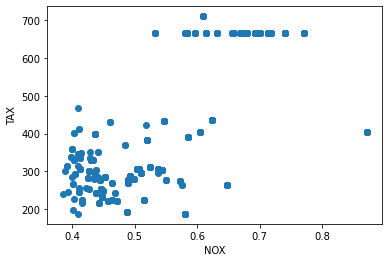

In [4]:
xs = df["NOX"]
ys = df["TAX"]

plt.scatter(xs, ys)
plt.xlabel("NOX")
plt.ylabel("TAX")
plt.show()

### estandardização

Vamos aplicar a padronização, transformando as variáveis ​​para que tenham média $ (\mu = 0) $ e desvio padrão $ (\sigma = 1) $, aplicando a fórmula:

$$ x' = \frac{x - \mu}{\sigma}$$

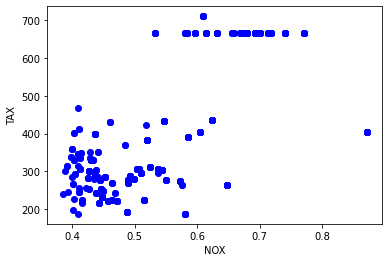

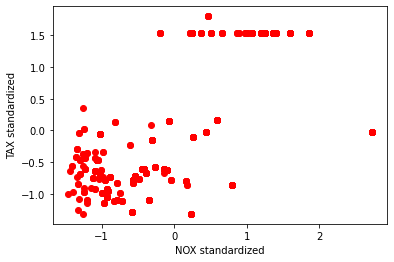

In [5]:
xs = df["NOX"]
ys = df["TAX"]
plt.scatter(xs, ys, color = 'b')
plt.xlabel("NOX")
plt.ylabel("TAX")
plt.show()

xs = df["NOX"]
mean = np.mean(xs)
std = np.std(xs)
xs = [(x - mean) / std for x in xs]

ys = df["TAX"]
mean = np.mean(ys)
std = np.std(ys)
ys = [(y - mean) / std for y in ys]

plt.scatter(xs, ys, color = 'r')
plt.xlabel("NOX standardized")
plt.ylabel("TAX standardized")
plt.show()

Se observarmos a forma do histograma de uma variável individual, vemos que A dispersão dos pontos não muda, apenas muda a escala em que a variável é expressa.

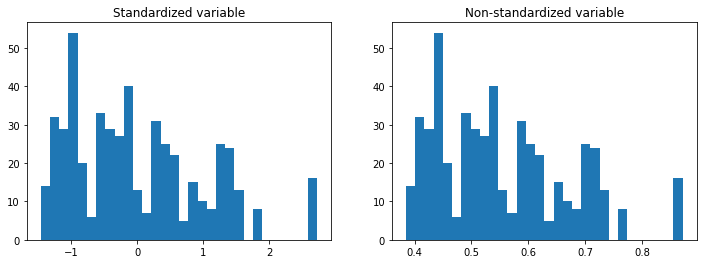

In [6]:
plt.figure(figsize = (12,4))
ax1 = plt.subplot(121)
ax1.set_title("Standardized variable")
ax1.hist(xs,bins=30);

ax2 = plt.subplot(122)
ax2.set_title("Non-standardized variable")
ax2.hist(df["NOX"], bins = 30);

Como você pode ver, não mudamos a forma dos dados, apenas sua escala.

Também podemos usar o [`scikit-learn`](https://scikit-learn.org/stable/modules/preprocessing.html) para padronizar variáveis.

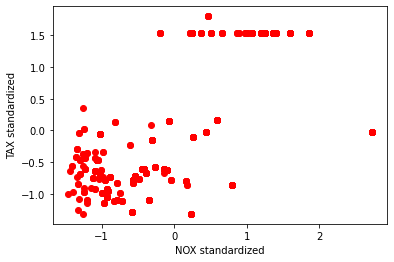

In [7]:
from sklearn import preprocessing

xs = preprocessing.scale(df["NOX"])
ys = preprocessing.scale(df["TAX"])

plt.scatter(xs, ys, color = 'r')
plt.xlabel("NOX standardized")
plt.ylabel("TAX standardized")
plt.show()

### Normalização Min-Max


A [normalização Min-Max](https://towardsdatascience.com/everything-you-need-to-know-about-min-max-normalization-in-python-b79592732b79) reescalona o conjunto de dados em termos da diferença entro os valores mínimo e máximo da variável reescalonada. Aplicamos a seguinte transformação:

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

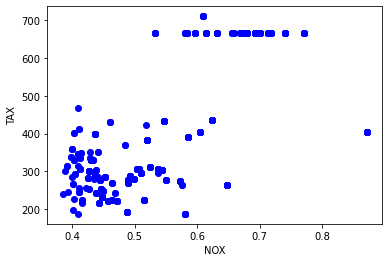

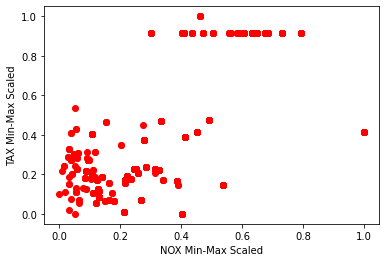

In [8]:
xs = df["NOX"]
ys = df["TAX"]
plt.scatter(xs, ys, color = 'b')
plt.xlabel("NOX")
plt.ylabel("TAX")
plt.show()

xs = df["NOX"]
xmin = np.min(xs)
xmax = np.max(xs)
xs = [(x - xmin) / (xmax - xmin) for x in xs]

ys = df["TAX"]
ymin = np.min(ys)
ymax = np.max(ys)
ys = [(y - ymin) / (ymax - ymin) for y in ys]

plt.scatter(xs, ys, color = 'r')
plt.xlabel("NOX Min-Max Scaled")
plt.ylabel("TAX Min-Max Scaled")
plt.show()

Verificamos o histograma de uma das variáveis reescalonadas.

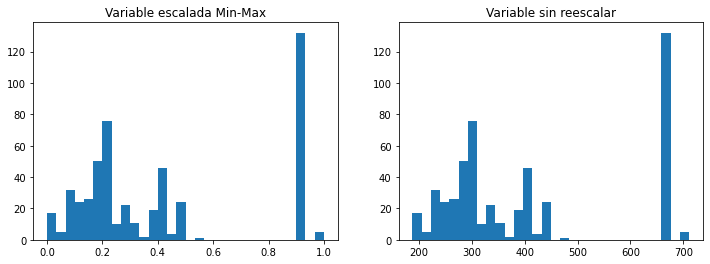

In [9]:
plt.figure(figsize = (12, 4))
ax1 = plt.subplot(121)
ax1.set_title("Variable escalada Min-Max")
ax1.hist(ys, bins = 30);

ax2 = plt.subplot(122)
ax2.set_title("Variable sin reescalar")
ax2.hist(df["TAX"], bins = 30);

Este tipo de normalização também pode ser alcançado usando o `scikit-learn`.

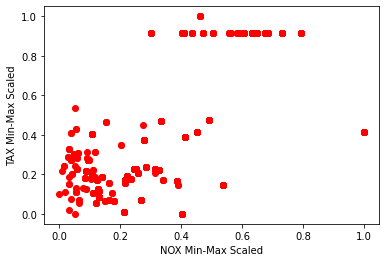

In [10]:
from sklearn import preprocessing

scaler = preprocessing.MinMaxScaler()

xs = scaler.fit_transform(df[["NOX"]])
ys = scaler.fit_transform(df[["TAX"]])

plt.scatter(xs, ys, color = 'r')
plt.xlabel("NOX Min-Max Scaled")
plt.ylabel("TAX Min-Max Scaled")
plt.show()

In [11]:
x = [10, 13, 17, 20]
preprocessing.scale(x)

array([-1.31306433, -0.52522573,  0.52522573,  1.31306433])

### Otras formas de normalizar

En algunos casos, normalizamos los datos dividiendo por algún tipo de sumatoria. Por ejemplo, es habitual normalizar diviendo por la suma de x (norma L1):

$|X| = \sum_{}{|x|}$

o por la raíz de la suma de los cuadrados de x (norma L2)

$||X|| = \sqrt{\sum_{}{x^2}}$. 



### Outras maneiras de normalizar

Em alguns casos, normalizamos os dados dividindo por algum tipo de soma. Por exemplo, é comum normalizar dividindo pela soma de $x$ ([norma L1](https://www.tutorialspoint.com/machine_learning_with_python/machine_learning_with_python_lone_normalization.htm)):

$ | X | = \sum_{i} {| x_{i} |} $

ou pela raiz da soma dos quadrados de $x$ ([norma L2](https://www.tutorialspoint.com/machine_learning_with_python/machine_learning_with_python_ltwo_normalization.htm))

$ || X || = \sqrt{\sum_{i} {x_{i}^{2}}} $.

# Prática guiada

Aplicaremos uma normalização usando a norma e o gráfico $L1$ e $L2$, como fizemos com os outros métodos de normalização.

Em seguida, repetiremos o exercício, desta vez usando a biblioteca [scikit-learn](http://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-normalization).

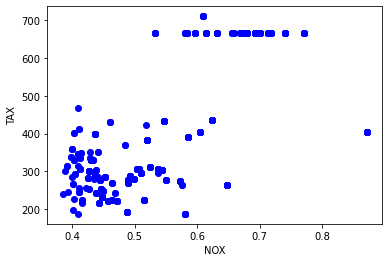

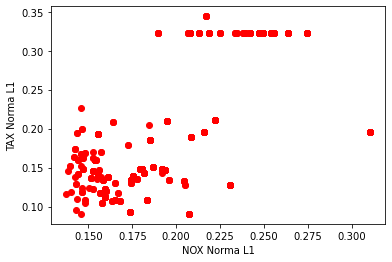

In [12]:
xs = df["NOX"]
ys = df["TAX"]
plt.scatter(xs, ys, color = 'b')
plt.xlabel("NOX")
plt.ylabel("TAX")
plt.show()

xs = df["NOX"]
ys = df["TAX"]

# Normalizamos xs e ys com a norma L1
# ....
df["xs_l1"] = df["NOX"] / np.sum(np.abs(df["NOX"]))
df["ys_l1"] = df["TAX"] / np.sum(np.abs(df["TAX"]))

# A escala do gráfico de dispersão parece muito pequena com L1 e é impossível de visualizar.
# Você pode tentar multiplicar cada vetor por 100 para verificar se a forma dos dados permanece inalterada.

plt.scatter(df["xs_l1"] * 100, df["ys_l1"] * 100, color = 'r')

plt.xlabel("NOX Norma L1")
plt.ylabel("TAX Norma L1")
plt.show()

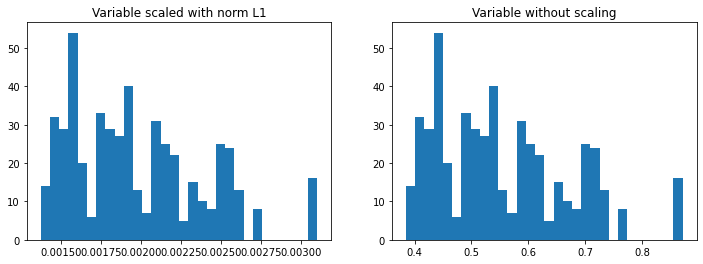

In [13]:
#Verificamos o histograma de uma das variáveis reescalonadas.

plt.figure(figsize = (12, 4))
ax1 = plt.subplot(121)
ax1.set_title("Variable scaled with norm L1")
ax1.hist(df["xs_l1"], bins = 30);

ax2 = plt.subplot(122)
ax2.set_title("Variable without scaling")
ax2.hist(df["NOX"], bins = 30);

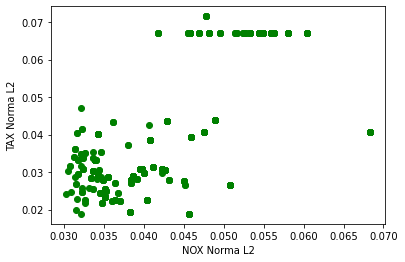

In [14]:
xs = df["NOX"]
ys = df["TAX"]

# Normalizamos xs e ys con norma L2
# ....

xs_l2 = df["NOX"] / np.sqrt(np.sum(df["NOX"] ** 2))
ys_l2 = df["TAX"] / np.sqrt(np.sum(df["TAX"] ** 2))

plt.scatter(xs_l2, ys_l2, color = 'g')
plt.xlabel("NOX Norma L2")
plt.ylabel("TAX Norma L2")
plt.show()

Verificamos o histograma de uma das variáveis reescalonadas.

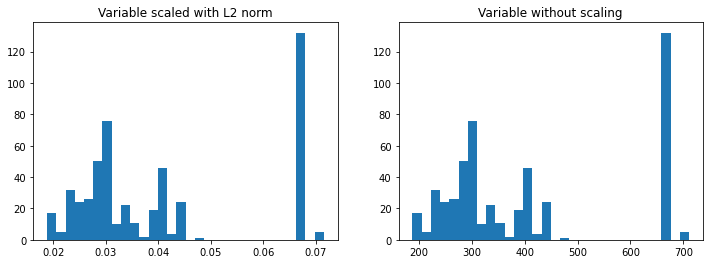

In [15]:
plt.figure(figsize = (12, 4))
ax1 = plt.subplot(121)
ax1.set_title("Variable scaled with L2 norm")
ax1.hist(ys_l2, bins = 30);

ax2 = plt.subplot(122)
ax2.set_title("Variable without scaling")
ax2.hist(df["TAX"], bins = 30);

Agora usando `Sklearn`, com [`sklearn.preprocessing.normalize()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html) sobre `xs` e `ys`

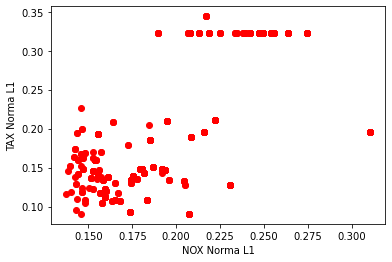

In [16]:
xs = df["NOX"]
ys = df["TAX"]
X = df[["TAX","NOX"]]
#....

X = preprocessing.normalize(X, norm = 'l1', axis = 0)
plt.scatter(X[ : , 1] * 100, X[ : , 0] * 100, color = 'r')
plt.xlabel("NOX Norma L1")
plt.ylabel("TAX Norma L1")
plt.show()